Program Pemodelan ANN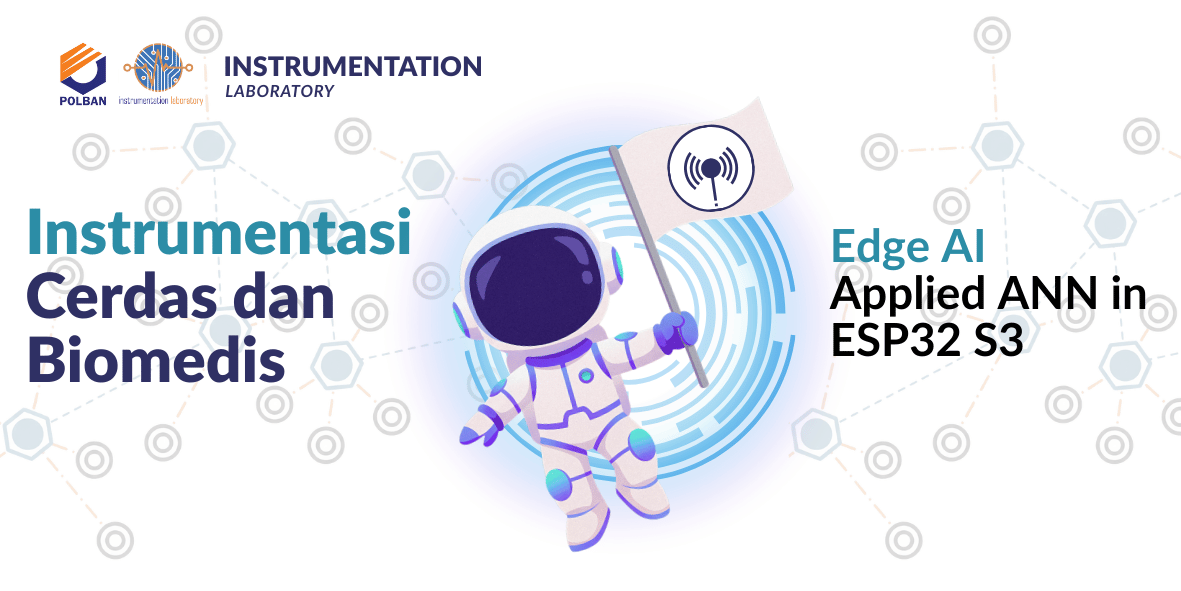

#**Visualisasi Data**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#1. Load Dataset
data_path = "dataset_kenyamanan.csv"
df = pd.read_csv(data_path)

print('--- Analisis Statistik Deskriptif ---')
print(df.describe())

--- Analisis Statistik Deskriptif ---
       temperature     humidity  comfort_score
count  1000.000000  1000.000000    1000.000000
mean     28.049840    61.823410       6.591700
std       5.727571    18.147573       1.837536
min      18.010000    30.060000       1.900000
25%      22.955000    46.950000       5.100000
50%      28.360000    61.265000       6.800000
75%      33.025000    76.742500       8.100000
max      37.980000    94.990000       9.900000


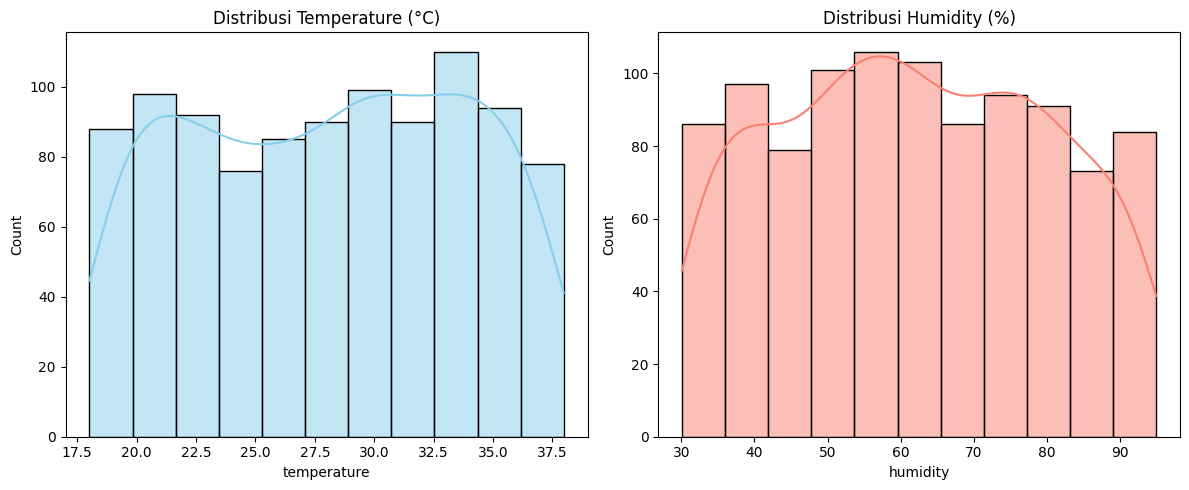

In [4]:
#2. Visualisasi Sebaran Data (Histogram & KDE)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['temperature'], kde=True, color='skyblue')
plt.title('Distribusi Temperature (°C)')

plt.subplot(1, 2, 2)
sns.histplot(df['humidity'], kde=True, color='salmon')
plt.title('Distribusi Humidity (%)')

plt.tight_layout()
plt.show()

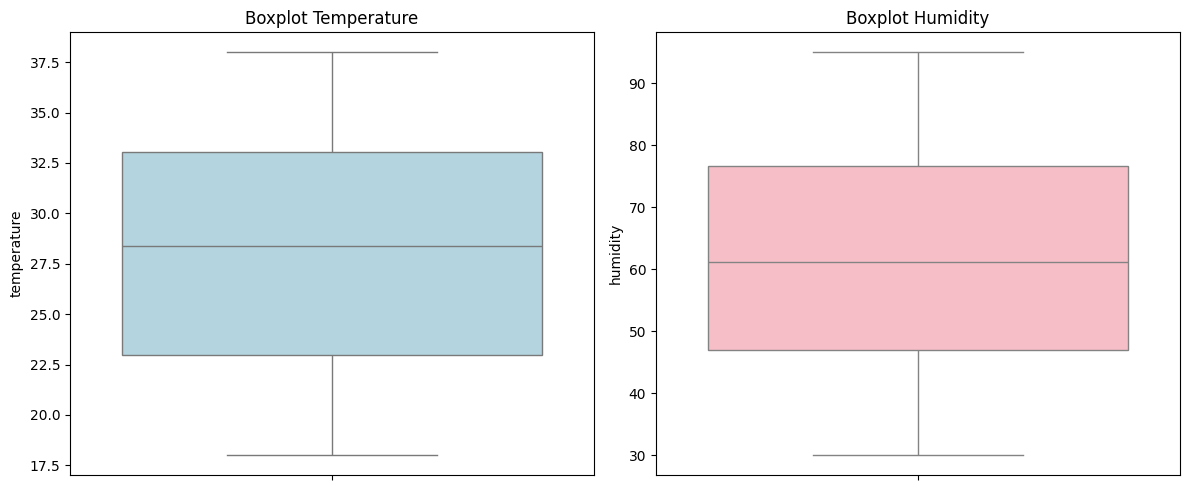

In [5]:
#3. Visualisasi Standar Deviasi & Outliers (Boxplot)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['temperature'], color='lightblue')
plt.title('Boxplot Temperature')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['humidity'], color='lightpink')
plt.title('Boxplot Humidity')

plt.tight_layout()
plt.show()

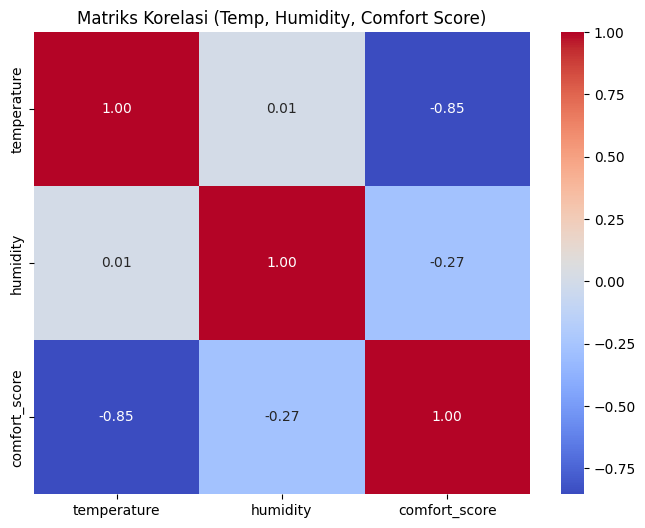

In [6]:
#4. Matriks Korelasi (Heatmap)
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi (Temp, Humidity, Comfort Score)')
plt.show()

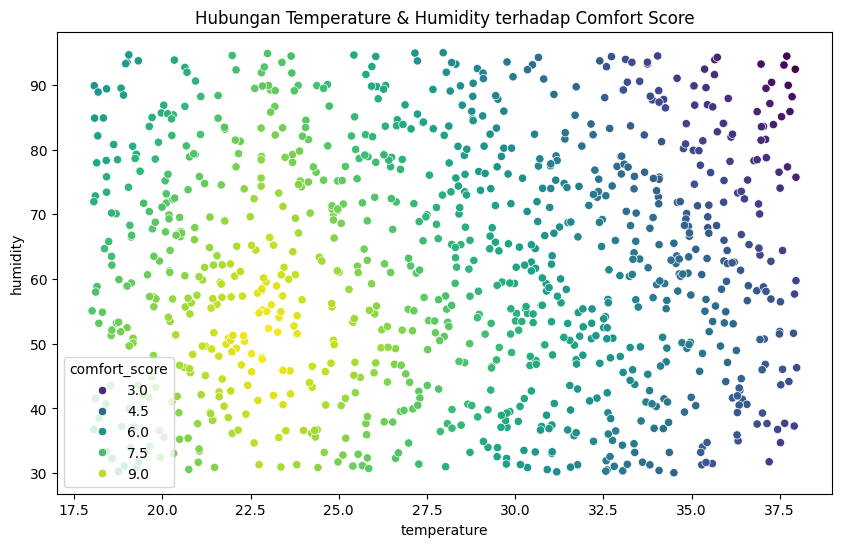

In [7]:
#5. Scatter Plot Hubungan Fitur
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temperature', y='humidity', hue='comfort_score', data=df, palette='viridis')
plt.title('Hubungan Temperature & Humidity terhadap Comfort Score')
plt.show()

# Generate Model ESP32 S3 ANN

--- Memulai Proses Training Model Kenyamanan Lingkungan (Edge AI) ---
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0790 - mae: 0.2344 - val_loss: 0.0661 - val_mae: 0.2168
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0649 - mae: 0.2140 - val_loss: 0.0596 - val_mae: 0.2064
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0598 - mae: 0.2052 - val_loss: 0.0556 - val_mae: 0.2007
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0532 - mae: 0.1943 - val_loss: 0.0478 - val_mae: 0.1859
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0462 - mae: 0.1809 - val_loss: 0.0406 - val_mae: 0.1714
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0409 - mae: 0.1703 - val_loss: 0.0340 - val_mae: 0.1570
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0347 - mae: 0.1572 - val_loss: 0.0283 - val_mae: 0.1431
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0253 - mae: 0.1334 - val_loss: 0.0230 - val_mae: 0.1290
Epoch 9/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0228 - mae: 0.1

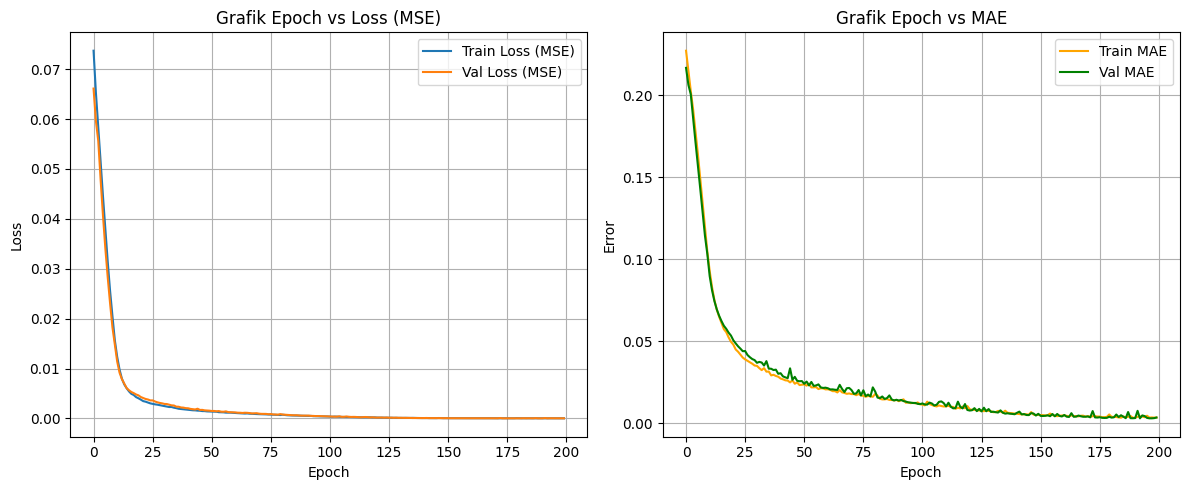

Saved artifact at '/tmp/tmpucq5bi0y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132229249410320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132229249413008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132229249411664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132229249409552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132229249413584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132229249410512: TensorSpec(shape=(), dtype=tf.resource, name=None)

Training Selesai. Final MSE: 0.000018
File model_data.h siap di-deploy ke ESP32-S3!


In [8]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('--- Memulai Proses Training Model Kenyamanan Lingkungan (Edge AI) ---')

# 1. Load Dataset
# Pastikan dataset_kenyamanan.csv sudah diupload
data_path = "dataset_kenyamanan.csv"
df = pd.read_csv(data_path)

X = df[['temperature', 'humidity']].values
y = df['comfort_score'].values

# 2. Normalisasi Sederhana (Crucial untuk konvergensi ANN)
# Temperature (0-40), Humidity (0-100), Score (0-10)
X_norm = X / np.array([40.0, 100.0])
y_norm = y / 10.0

# 3. Membangun Arsitektur Model
def create_model(input_size):
    model = Sequential([
        Dense(16, activation='relu', input_shape=(input_size,), name="Hidden_1"),
        Dense(8, activation='relu', name="Hidden_2"),
        Dense(1, name="Output")
    ])
    return model

input_size = 2
learning_rate = 0.001
num_epochs = 200

model = create_model(input_size)
model.compile(optimizer=Adam(learning_rate=learning_rate),
              loss='mean_squared_error',
              metrics=['mae'])

# 4. Training Model & Menyimpan History
# validation_split digunakan untuk memantau performa data yang belum pernah dilihat model
history = model.fit(X_norm, y_norm,
                    epochs=num_epochs,
                    batch_size=16,
                    validation_split=0.2,
                    verbose=1)

# 5. Visualisasi Hasil Training
print("\n--- Visualisasi Performa Model ---")
plt.figure(figsize=(12, 5))

# Plot Grafik Epoch vs Loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Grafik Epoch vs Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Grafik Epoch vs Mean Absolute Error (MAE)
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE', color='orange')
plt.plot(history.history['val_mae'], label='Val MAE', color='green')
plt.title('Grafik Epoch vs MAE')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 6. Simpan Model & Konversi ke TFLite
model.save('ComfortModel.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("comfort_model.tflite", "wb") as f:
    f.write(tflite_model)

# 7. Generate Header File untuk ESP32-S3
!xxd -i comfort_model.tflite > model_data.h

final_mse = history.history['loss'][-1]
print(f"\nTraining Selesai. Final MSE: {final_mse:.6f}")
print("File model_data.h siap di-deploy ke ESP32-S3!")

# TEST MODEL

In [14]:
import tensorflow as tf
import numpy as np

# 1. Load model dari file fisik ke dalam variabel 'my_model'
# Pastikan nama file sesuai dengan yang ada di sidebar (ComfortModel.h5)
my_model = tf.keras.models.load_model('ComfortModel.h5')

def predict_manual(temp, humi):
    # 2. Normalisasi input (Sama seperti saat training: /40 dan /100)
    input_data = np.array([[temp/40.0, humi/100.0]], dtype=np.float32)

    # 3. Gunakan variabel 'my_model' untuk prediksi, bukan nama filenya
    prediction = my_model.predict(input_data)

    # 4. Denormalisasi output (*10)
    return prediction[0][0] * 10.0

# --- Uji Coba ---
temp_test = 18
humi_test = 10
hasil = predict_manual(temp_test, humi_test)

print(f"\nPrediksi Comfort Score untuk {temp_test}°C & {humi_test}% RH: {hasil:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

Prediksi Comfort Score untuk 18°C & 10% RH: 6.23
